In [1]:
# ============================================================
# CELL 1: Import & Setup
# ============================================================
import os, random, time, json, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)
os.makedirs('outputs', exist_ok=True)

Device: cpu


In [2]:
# ============================================================
# CELL 2: Load dữ liệu đã xử lý
# ============================================================
amzn = np.load('data/amzn_processed.npz')
retail = np.load('data/retail_processed.npz')

X_train_a, y_train_a = amzn['X_train'], amzn['y_train']
X_val_a,   y_val_a   = amzn['X_val'],   amzn['y_val']
X_test_a,  y_test_a  = amzn['X_test'],  amzn['y_test']
y_min_a, y_range_a = amzn['y_mean'][0], amzn['y_scale'][0]

X_train_r, y_train_r = retail['X_train'], retail['y_train']
X_val_r,   y_val_r   = retail['X_val'],   retail['y_val']
X_test_r,  y_test_r  = retail['X_test'],  retail['y_test']

print("Amazon:", X_train_a.shape, X_val_a.shape, X_test_a.shape)
print("Retail:", X_train_r.shape, X_val_r.shape, X_test_r.shape)

Amazon: (4648, 30, 5) (972, 30, 5) (974, 30, 5)
Retail: (395001, 10, 4) (84643, 10, 4) (84644, 10, 4)


In [3]:
# ============================================================
# CELL 3: Định nghĩa mô hình RNN cho Regression (AMZN)
# ============================================================
class RNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, nonlinearity='tanh',
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # out: (B, T, H)
        out = out[:, -1, :]          # lấy hidden cuối
        return self.fc(out).squeeze(-1)

In [4]:
# ============================================================
# CELL 4: Hàm train dùng chung
# ============================================================
def train_regressor(model, train_loader, val_loader, epochs=60, lr=1e-3, patience=10):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val = float('inf'); best_state = None; wait = 0
    history = {'train_loss': [], 'val_loss': []}

    for ep in range(1, epochs + 1):
        model.train(); tr_loss = 0; n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(xb); n += len(xb)
        tr_loss /= n

        model.eval(); vl_loss = 0; n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                vl_loss += criterion(pred, yb).item() * len(xb); n += len(xb)
        vl_loss /= n

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_loss < best_val - 1e-5:
            best_val = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep}")
                break

        if ep % 5 == 0 or ep == 1:
            print(f"Epoch {ep:02d} | Train: {tr_loss:.6f} | Val: {vl_loss:.6f}")

    model.load_state_dict(best_state)
    return model, history, best_val

In [5]:
# ============================================================
# CELL 5: Train AMZN PyTorch
# ============================================================
BATCH = 32
train_ds = TensorDataset(torch.from_numpy(X_train_a), torch.from_numpy(y_train_a))
val_ds   = TensorDataset(torch.from_numpy(X_val_a),   torch.from_numpy(y_val_a))
test_ds  = TensorDataset(torch.from_numpy(X_test_a),  torch.from_numpy(y_test_a))

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

torch.manual_seed(SEED)
pt_amzn = RNNRegressor(input_size=X_train_a.shape[-1], hidden_size=64, num_layers=1)
t0 = time.time()
pt_amzn, hist_amzn, best_val = train_regressor(pt_amzn, train_loader, val_loader,
                                                epochs=60, lr=1e-3, patience=10)
pt_time = time.time() - t0
print(f"\nPyTorch AMZN - Training time: {pt_time:.2f}s")

Epoch 01 | Train: 0.001271 | Val: 0.247163
Epoch 05 | Train: 0.000061 | Val: 0.119463
Epoch 10 | Train: 0.000053 | Val: 0.114079
Epoch 15 | Train: 0.000043 | Val: 0.113550
Epoch 20 | Train: 0.000041 | Val: 0.132993
Early stop at epoch 22

PyTorch AMZN - Training time: 36.22s


PyTorch AMZN Test: MAE=1.5135 | RMSE=1.6367 | R2=-3.1182 | MAPE=35.52%


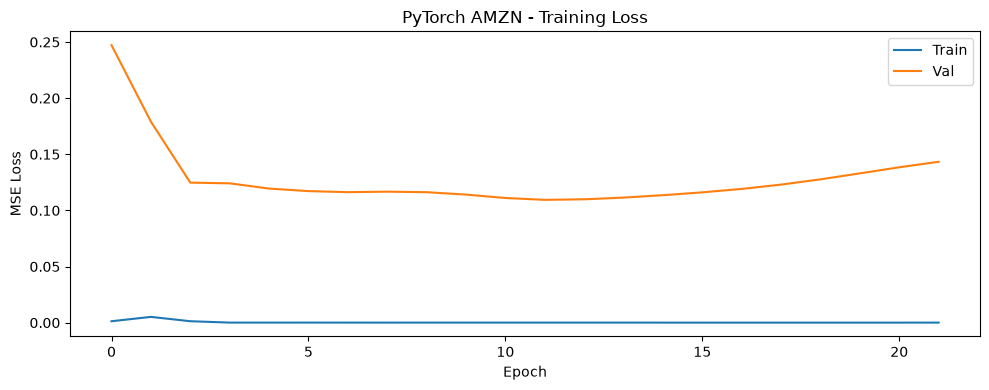

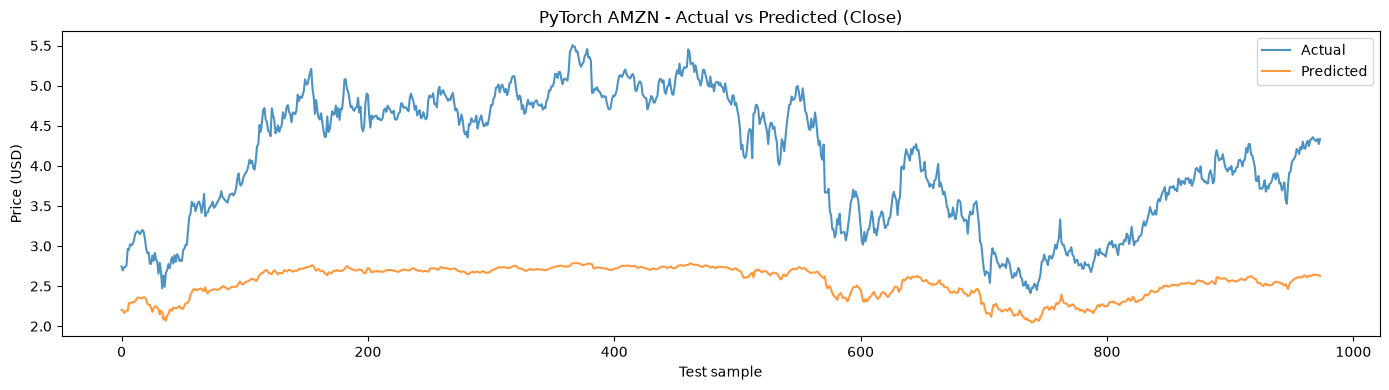

In [6]:
# ============================================================
# CELL 6: Đánh giá AMZN PyTorch
# ============================================================
pt_amzn.eval()
with torch.no_grad():
    pred_test = pt_amzn(torch.from_numpy(X_test_a).to(DEVICE)).cpu().numpy()

# Inverse scale
pred_test_real = pred_test * y_range_a + y_min_a
y_test_real    = y_test_a * y_range_a + y_min_a

mae = mean_absolute_error(y_test_real, pred_test_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_test_real))
r2 = r2_score(y_test_real, pred_test_real)
mape = np.mean(np.abs((y_test_real - pred_test_real) / y_test_real)) * 100

print(f"PyTorch AMZN Test: MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | MAPE={mape:.2f}%")

pt_amzn_metrics = {'MAE': float(mae), 'RMSE': float(rmse),
                   'R2': float(r2), 'MAPE': float(mape),
                   'time': pt_time, 'best_val': float(best_val)}

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(hist_amzn['train_loss'], label='Train')
plt.plot(hist_amzn['val_loss'], label='Val')
plt.title('PyTorch AMZN - Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend()
plt.tight_layout()
plt.savefig('outputs/02_pt_amzn_loss.png', dpi=200)
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(14, 4))
plt.plot(y_test_real, label='Actual', alpha=0.8)
plt.plot(pred_test_real, label='Predicted', alpha=0.8)
plt.title('PyTorch AMZN - Actual vs Predicted (Close)')
plt.xlabel('Test sample'); plt.ylabel('Price (USD)'); plt.legend()
plt.tight_layout()
plt.savefig('outputs/02_pt_amzn_pred.png', dpi=200)
plt.show()

In [7]:
# ============================================================
# CELL 7: Định nghĩa mô hình RNN cho Classification (Retail)
# ============================================================
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, nonlinearity='tanh',
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)   # logits


def train_classifier(model, train_loader, val_loader, epochs=30, lr=1e-3, patience=8,
                     pos_weight=None):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val = float('inf'); best_state = None; wait = 0
    history = {'train_loss': [], 'val_loss': []}

    for ep in range(1, epochs + 1):
        model.train(); tr_loss = 0; n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(xb); n += len(xb)
        tr_loss /= n

        model.eval(); vl_loss = 0; n = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                vl_loss += criterion(logits, yb).item() * len(xb); n += len(xb)
        vl_loss /= n
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_loss < best_val - 1e-5:
            best_val = vl_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep}")
                break
        if ep % 3 == 0 or ep == 1:
            print(f"Epoch {ep:02d} | Train: {tr_loss:.6f} | Val: {vl_loss:.6f}")

    model.load_state_dict(best_state)
    return model, history, best_val

In [8]:
# ============================================================
# CELL 8: Train Retail PyTorch
# ============================================================
BATCH_R = 64
train_ds_r = TensorDataset(torch.from_numpy(X_train_r), torch.from_numpy(y_train_r))
val_ds_r   = TensorDataset(torch.from_numpy(X_val_r),   torch.from_numpy(y_val_r))
test_ds_r  = TensorDataset(torch.from_numpy(X_test_r),  torch.from_numpy(y_test_r))

train_loader_r = DataLoader(train_ds_r, batch_size=BATCH_R, shuffle=True)
val_loader_r   = DataLoader(val_ds_r,   batch_size=BATCH_R, shuffle=False)
test_loader_r  = DataLoader(test_ds_r,  batch_size=BATCH_R, shuffle=False)

# Xử lý imbalance
pos = y_train_r.sum()
neg = len(y_train_r) - pos
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32).to(DEVICE)
print(f"pos_weight = {pos_weight.item():.4f}")

torch.manual_seed(SEED)
pt_retail = RNNClassifier(input_size=X_train_r.shape[-1], hidden_size=64, num_layers=1)
t0 = time.time()
pt_retail, hist_retail, best_val_r = train_classifier(pt_retail, train_loader_r, val_loader_r,
                                                       epochs=30, lr=1e-3, patience=8,
                                                       pos_weight=pos_weight)
pt_time_r = time.time() - t0
print(f"\nPyTorch Retail - Training time: {pt_time_r:.2f}s")

pos_weight = 18.4429
Epoch 01 | Train: 1.215840 | Val: 1.222207
Epoch 03 | Train: 1.208245 | Val: 1.231417
Epoch 06 | Train: 1.202907 | Val: 1.189817
Epoch 09 | Train: 1.198990 | Val: 1.215159
Epoch 12 | Train: 1.197984 | Val: 1.202181
Early stop at epoch 14

PyTorch Retail - Training time: 534.26s


PyTorch Retail Test:
  Acc=0.7315 | Prec=0.1095 | Rec=0.5916 | F1=0.1848 | AUC=0.6959

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9709    0.7391    0.8393     80290
         1.0     0.1095    0.5916    0.1848      4354

    accuracy                         0.7315     84644
   macro avg     0.5402    0.6654    0.5120     84644
weighted avg     0.9266    0.7315    0.8056     84644



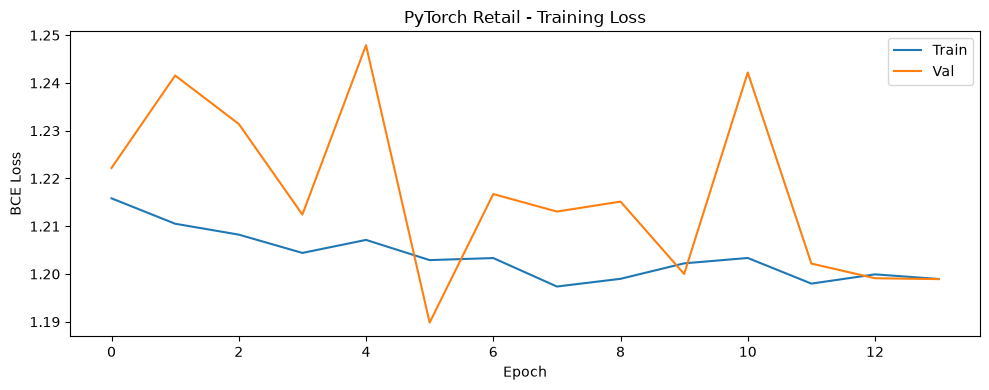

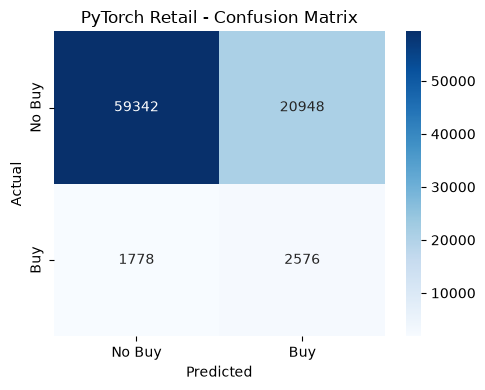

In [9]:
# ============================================================
# CELL 9: Đánh giá Retail PyTorch
# ============================================================
pt_retail.eval()
with torch.no_grad():
    logits = pt_retail(torch.from_numpy(X_test_r).to(DEVICE)).cpu().numpy()
probs = 1 / (1 + np.exp(-logits))
preds = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test_r, preds)
prec = precision_score(y_test_r, preds, zero_division=0)
rec = recall_score(y_test_r, preds, zero_division=0)
f1 = f1_score(y_test_r, preds, zero_division=0)
auc = roc_auc_score(y_test_r, probs)
cm = confusion_matrix(y_test_r, preds)

print(f"PyTorch Retail Test:")
print(f"  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_r, preds, digits=4, zero_division=0))

pt_retail_metrics = {'accuracy': float(acc), 'precision': float(prec),
                     'recall': float(rec), 'f1': float(f1), 'auc': float(auc),
                     'time': pt_time_r, 'best_val': float(best_val_r)}

# Plot loss
plt.figure(figsize=(10, 4))
plt.plot(hist_retail['train_loss'], label='Train')
plt.plot(hist_retail['val_loss'], label='Val')
plt.title('PyTorch Retail - Training Loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss'); plt.legend()
plt.tight_layout()
plt.savefig('outputs/02_pt_retail_loss.png', dpi=200)
plt.show()

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Buy', 'Buy'], yticklabels=['No Buy', 'Buy'])
plt.title('PyTorch Retail - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/02_pt_retail_cm.png', dpi=200)
plt.show()

In [11]:
# ============================================================
# CELL 10: Lưu kết quả PyTorch
# ============================================================
results = {
    'amzn': pt_amzn_metrics,
    'retail': pt_retail_metrics,
    'hist_amzn': hist_amzn,
    'hist_retail': hist_retail,
    'pred_amzn': pred_test_real.tolist(),
    'y_amzn': y_test_real.tolist(),
    'pred_retail': probs.tolist(),
    'y_retail': y_test_r.tolist(),
}
with open('outputs/pytorch_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Đã lưu outputs/pytorch_results.json")

Đã lưu outputs/pytorch_results.json
